# 09. Matrix factorisation with SVD

## Purpose
This notebook implements a matrix factorisation recommender using truncated SVD on the
chronological implicit interaction data.

The model learns latent user and item factors from the training split only and uses these
latent representations to generate Top-N recommendations for evaluation on validation and
test splits.

This notebook builds on earlier phases:
- Phase 04 created modelling-ready datasets
- Phase 05 created chronological train / validation / test splits
- Phase 07 implemented the popularity baseline
- Phase 08 implemented neighbourhood-based collaborative filtering

## Main tasks
- load chronological implicit train, validation, and test splits
- use the train-fitted mapped indices from Phase 5
- build a sparse user-item interaction matrix
- fit a truncated SVD model on the training matrix only
- reconstruct latent preference scores
- generate Top-N recommendations for each user
- exclude items already seen in training
- evaluate ranking quality on validation and test
- analyse catalogue coverage, novelty, and popularity concentration
- save outputs for later comparison and dashboard use

In [2]:
from __future__ import annotations

import json
import math
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse
from sklearn.decomposition import TruncatedSVD

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 120)

## 1. Set project paths

Set project paths and create output subdirectories for the SVD phase.

In [3]:
PROJECT_ROOT = Path.cwd().resolve().parents[0]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.paths import (
    SPLITS_DIR,
    TABLES_DIR,
    FIGURES_DIR,
    LOGS_DIR,
    ensure_directories,
)

MODEL_NAME = "svd"
TOP_K_VALUES = [5, 10, 20]
EXPORT_TOP_N = 10

# Main tunable hyperparameters
N_COMPONENTS = 64
RANDOM_STATE = 42
N_ITER = 10

TABLES_SUBDIR = TABLES_DIR / MODEL_NAME
FIGURES_SUBDIR = FIGURES_DIR / MODEL_NAME
LOGS_SUBDIR = LOGS_DIR / MODEL_NAME

ensure_directories()
TABLES_SUBDIR.mkdir(parents=True, exist_ok=True)
FIGURES_SUBDIR.mkdir(parents=True, exist_ok=True)
LOGS_SUBDIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Split directory:", SPLITS_DIR)
print("Tables output:", TABLES_SUBDIR)
print("Figures output:", FIGURES_SUBDIR)
print("Logs output:", LOGS_SUBDIR)

Project root: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project
Split directory: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits
Tables output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\tables\svd
Figures output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\figures\svd
Logs output: E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\outputs\logs\svd


## 2. Load implicit chronological splits

The SVD model is fitted on the implicit interaction split so that it uses the full observed
user-recipe interaction history rather than only explicit ratings.

These splits were created in Phase 5 and already include train-fitted `user_idx` and `item_idx`
columns needed for matrix construction.

In [4]:
train_path = SPLITS_DIR / "implicit_train.parquet"
valid_path = SPLITS_DIR / "implicit_valid.parquet"
test_path = SPLITS_DIR / "implicit_test.parquet"

for path in [train_path, valid_path, test_path]:
    print(path, "exists:", path.exists())

implicit_train = pd.read_parquet(train_path).copy()
implicit_valid = pd.read_parquet(valid_path).copy()
implicit_test = pd.read_parquet(test_path).copy()

print("Implicit train shape:", implicit_train.shape)
print("Implicit valid shape:", implicit_valid.shape)
print("Implicit test shape:", implicit_test.shape)

display(implicit_train.head(3))
display(implicit_valid.head(3))
display(implicit_test.head(3))

E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_train.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_valid.parquet exists: True
E:\UWE\Class Notes\Year 3\Digital Systems Project\Project V2\project\data\splits\implicit_test.parquet exists: True
Implicit train shape: (792656, 9)
Implicit valid shape: (169855, 9)
Implicit test shape: (169856, 9)


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,2008,992,2000-01-25,5,1,0,1,11,410
1,2008,3603,2000-01-25,4,1,0,1,11,1154
2,2046,517,2000-02-25,5,1,0,1,13,250


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,242205,55768,2010-06-17,5,1,0,1,27992.0,30765.0
1,242729,391308,2010-06-17,5,1,0,1,28058.0,NaN
2,254446,223104,2010-06-17,5,1,0,1,29303.0,118077.0


,user_id,recipe_id,date,rating,review_exists,is_unrated_observation,implicit_feedback,user_idx,item_idx
0,141284,15646,2012-12-28,5,1,0,1,16396.0,7048.0
1,155896,41728,2012-12-28,4,1,0,1,18012.0,22676.0
2,158966,121583,2012-12-28,5,1,0,1,18380.0,68592.0


## 3. Inspect required columns

Confirm that the split datasets contain the columns needed for matrix factorisation and
Top-N evaluation.

In [5]:
required_cols = [
    "user_id",
    "recipe_id",
    "date",
    "implicit_feedback",
    "user_idx",
    "item_idx",
]

for split_name, df in {
    "train": implicit_train,
    "valid": implicit_valid,
    "test": implicit_test,
}.items():
    missing = [c for c in required_cols if c not in df.columns]
    print(split_name, "missing columns:", missing)

print("Train columns:")
print(sorted(implicit_train.columns.tolist()))

train missing columns: []
valid missing columns: []
test missing columns: []
Train columns:
['date', 'implicit_feedback', 'is_unrated_observation', 'item_idx', 'rating', 'recipe_id', 'review_exists', 'user_id', 'user_idx']


## 4. Check index coverage and evaluable rows

Validation and test may contain rows whose users or items were not present in the training
split mapping. These cannot be scored by the latent-factor model and should be quantified
explicitly rather than silently ignored.

In [6]:
def summarise_mapping_coverage(df: pd.DataFrame, split_name: str) -> pd.DataFrame:
    summary = pd.DataFrame(
        [
            {
                "split": split_name,
                "rows": int(len(df)),
                "missing_user_idx": int(df["user_idx"].isna().sum()),
                "missing_item_idx": int(df["item_idx"].isna().sum()),
                "rows_with_both_indices": int(
                    df["user_idx"].notna().mul(df["item_idx"].notna()).sum()
                ),
            }
        ]
    )
    summary["rows_evaluable_pct"] = round(
        summary["rows_with_both_indices"] / summary["rows"] * 100, 2
    )
    return summary

coverage_summary = pd.concat(
    [
        summarise_mapping_coverage(implicit_train, "train"),
        summarise_mapping_coverage(implicit_valid, "valid"),
        summarise_mapping_coverage(implicit_test, "test"),
    ],
    ignore_index=True,
)

coverage_summary

,split,rows,missing_user_idx,missing_item_idx,rows_with_both_indices,rows_evaluable_pct
0,train,792656,0,0,792656,100.00
1,valid,169855,48346,43718,86979,51.21
2,test,169856,115885,43126,35728,21.03


In [7]:
valid_svd = implicit_valid[
    implicit_valid["user_idx"].notna() & implicit_valid["item_idx"].notna()
].copy()

test_svd = implicit_test[
    implicit_test["user_idx"].notna() & implicit_test["item_idx"].notna()
].copy()

train_svd = implicit_train[
    implicit_train["user_idx"].notna() & implicit_train["item_idx"].notna()
].copy()

for df in [train_svd, valid_svd, test_svd]:
    df["user_idx"] = df["user_idx"].astype(int)
    df["item_idx"] = df["item_idx"].astype(int)

print("Train evaluable shape:", train_svd.shape)
print("Valid evaluable shape:", valid_svd.shape)
print("Test evaluable shape:", test_svd.shape)

Train evaluable shape: (792656, 9)
Valid evaluable shape: (86979, 9)
Test evaluable shape: (35728, 9)


## 5. Build the sparse user-item matrix

Construct the training interaction matrix using the train-fitted mapped user and item indices.
This matrix is the only source used for fitting latent factors.

In [8]:
n_users = int(train_svd["user_idx"].max()) + 1
n_items = int(train_svd["item_idx"].max()) + 1

train_matrix = sparse.csr_matrix(
    (
        train_svd["implicit_feedback"].astype(float).to_numpy(),
        (train_svd["user_idx"].to_numpy(), train_svd["item_idx"].to_numpy()),
    ),
    shape=(n_users, n_items),
)

print("Train matrix shape:", train_matrix.shape)
print("Train matrix nnz:", train_matrix.nnz)
print("Matrix density:", train_matrix.nnz / (train_matrix.shape[0] * train_matrix.shape[1]))

Train matrix shape: (106304, 186564)
Train matrix nnz: 792656
Matrix density: 3.996752914369524e-05


## 6. Inspect user and item interaction distributions

Review matrix sparsity and training interaction concentration before fitting SVD.

In [9]:
user_interaction_counts = np.asarray(train_matrix.getnnz(axis=1)).ravel()
item_interaction_counts = np.asarray(train_matrix.getnnz(axis=0)).ravel()

print(pd.Series(user_interaction_counts).describe())
print(pd.Series(item_interaction_counts).describe())

count    106304.000000
mean          7.456502
std          52.887636
min           1.000000
25%           1.000000
50%           1.000000
75%           3.000000
max        5056.000000
dtype: float64
count    186564.000000
mean          4.248708
std          12.849434
min           1.000000
25%           1.000000
50%           2.000000
75%           4.000000
max        1141.000000
dtype: float64


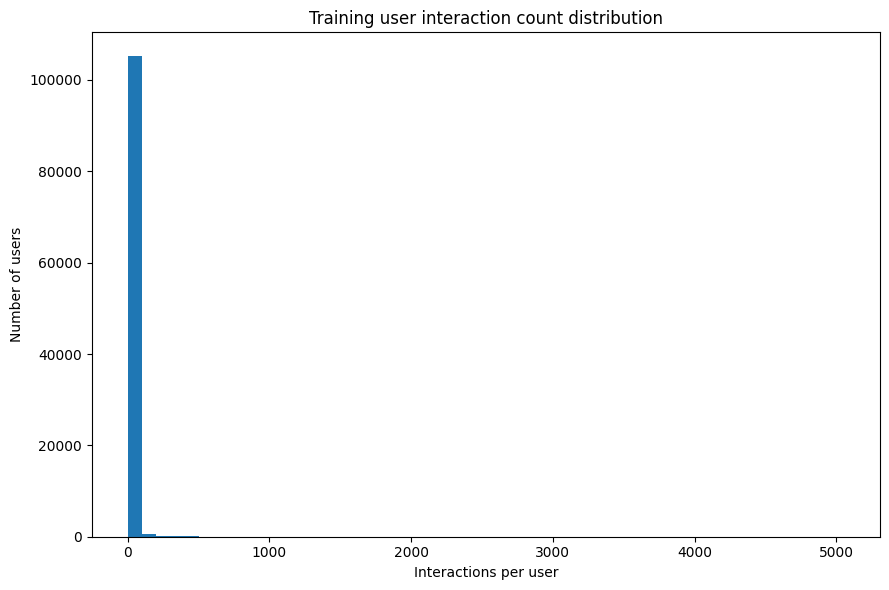

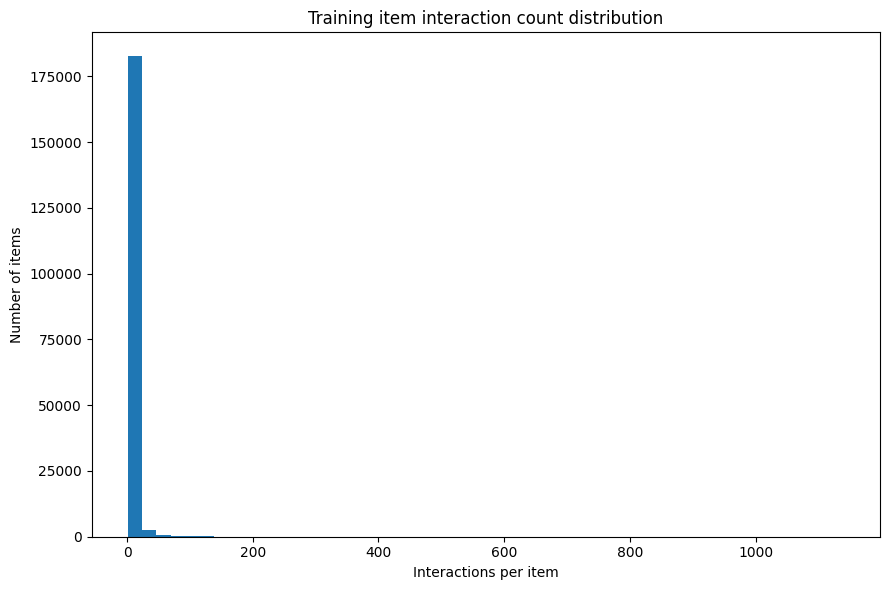

In [10]:
plt.figure(figsize=(9, 6))
plt.hist(user_interaction_counts, bins=50)
plt.xlabel("Interactions per user")
plt.ylabel("Number of users")
plt.title("Training user interaction count distribution")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.hist(item_interaction_counts, bins=50)
plt.xlabel("Interactions per item")
plt.ylabel("Number of items")
plt.title("Training item interaction count distribution")
plt.tight_layout()
plt.show()

## 7. Fit truncated SVD on the training matrix

Fit the latent-factor model on the training matrix only.

Truncated SVD is used here as a scalable matrix factorisation method for sparse implicit data.
The resulting user and item latent representations are then used to score unseen items.

In [11]:
svd_model = TruncatedSVD(
    n_components=N_COMPONENTS,
    n_iter=N_ITER,
    random_state=RANDOM_STATE,
)

user_factors = svd_model.fit_transform(train_matrix)
item_factors = svd_model.components_.T

print("User factors shape:", user_factors.shape)
print("Item factors shape:", item_factors.shape)
print("Explained variance ratio sum:", svd_model.explained_variance_ratio_.sum())

User factors shape: (106304, 64)
Item factors shape: (186564, 64)
Explained variance ratio sum: 0.1318843091974922


## 8. Summarise latent-factor fit

Inspect the explained variance profile and save a compact component summary.

In [12]:
component_summary = pd.DataFrame(
    {
        "component": np.arange(1, len(svd_model.explained_variance_ratio_) + 1),
        "explained_variance_ratio": svd_model.explained_variance_ratio_,
        "cumulative_explained_variance_ratio": np.cumsum(
            svd_model.explained_variance_ratio_
        ),
    }
)

display(component_summary.head(10))
display(component_summary.tail(10))

,component,explained_variance_ratio,cumulative_explained_variance_ratio
0,1,0.008607,0.008607
1,2,0.006345,0.014952
2,3,0.005212,0.020164
3,4,0.004276,0.024440
4,5,0.003742,0.028182
5,6,0.003434,0.031616
6,7,0.003322,0.034939
7,8,0.003072,0.038011
8,9,0.003000,0.041011
9,10,0.002847,0.043858


,component,explained_variance_ratio,cumulative_explained_variance_ratio
54,55,0.001277,0.120880
55,56,0.001263,0.122143
56,57,0.001253,0.123396
57,58,0.001245,0.124641
58,59,0.001235,0.125876
59,60,0.001229,0.127106
60,61,0.001206,0.128311
61,62,0.001198,0.129509
62,63,0.001193,0.130702
63,64,0.001183,0.131884


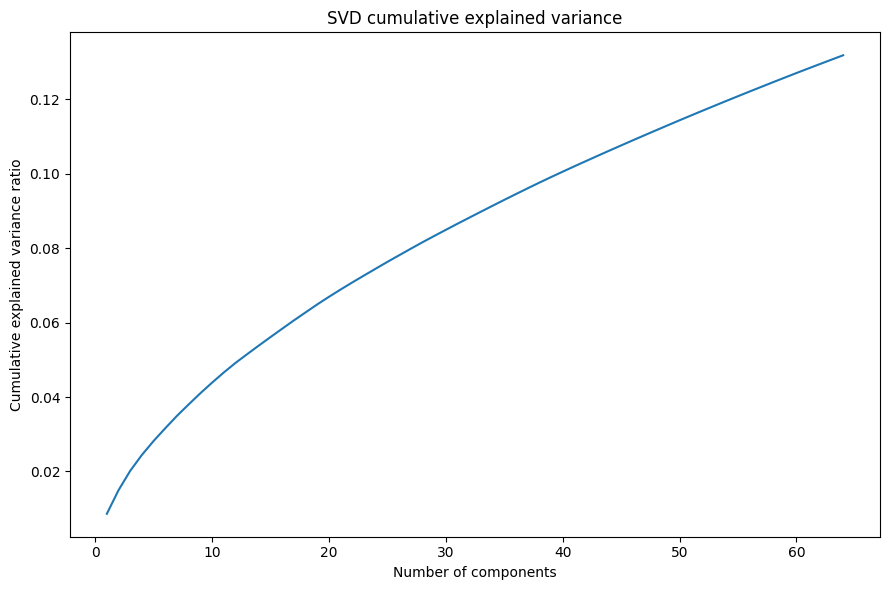

In [13]:
plt.figure(figsize=(9, 6))
plt.plot(
    component_summary["component"],
    component_summary["cumulative_explained_variance_ratio"],
)
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance ratio")
plt.title("SVD cumulative explained variance")
plt.tight_layout()
plt.show()

## 9. Build seen-item lookup from training data

Recommendations should exclude recipes already observed by each user in the training split.

In [14]:
seen_items_by_user = (
    train_svd.groupby("user_idx")["item_idx"]
    .apply(lambda s: set(s.astype(int).tolist()))
    .to_dict()
)

print("Users with seen-item sets:", len(seen_items_by_user))

Users with seen-item sets: 106304


## 10. Build ground-truth lookup for validation and test

For Top-N ranking evaluation, each user's relevant items in the holdout split are grouped into
sets of interacted recipes.

In [15]:
valid_truth = (
    valid_svd.groupby("user_idx")["item_idx"]
    .apply(lambda s: set(s.astype(int).tolist()))
    .to_dict()
)

test_truth = (
    test_svd.groupby("user_idx")["item_idx"]
    .apply(lambda s: set(s.astype(int).tolist()))
    .to_dict()
)

print("Validation users with ground truth:", len(valid_truth))
print("Test users with ground truth:", len(test_truth))

Validation users with ground truth: 12779
Test users with ground truth: 6048


## 11. Prepare item popularity reference for novelty analysis

Popularity from the training split is reused to measure whether recommendations are concentrated
on highly popular recipes or spread more broadly across the catalogue.

In [16]:
item_popularity = (
    train_svd.groupby(["item_idx", "recipe_id"])
    .size()
    .reset_index(name="train_interaction_count")
    .sort_values(["train_interaction_count", "item_idx"], ascending=[False, True])
    .reset_index(drop=True)
)

item_popularity["item_popularity_rank"] = np.arange(1, len(item_popularity) + 1)

popularity_lookup = item_popularity.set_index("item_idx")["train_interaction_count"].to_dict()
recipe_lookup = (
    train_svd[["item_idx", "recipe_id"]]
    .drop_duplicates()
    .set_index("item_idx")["recipe_id"]
    .to_dict()
)

item_popularity.head(10)

,item_idx,recipe_id,train_interaction_count,item_popularity_rank
0,14078,27208,1141,1
1,49883,89204,1054,2
2,21107,39087,923,3
3,17050,32204,911,4
4,11404,22782,799,5
5,37647,67256,754,6
6,29869,54257,725,7
7,13270,25885,688,8
8,38583,68955,687,9
9,14590,28148,672,10


## 12. Define recommendation and evaluation helpers

Helper functions are created for:
- scoring candidate items for a user
- extracting Top-N recommendations
- computing ranking metrics
- summarising beyond-accuracy measures

In [17]:
def precision_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if k == 0:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / k


def recall_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    hits = len(set(recommended[:k]) & relevant)
    return hits / len(relevant)


def hit_rate_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    return float(len(set(recommended[:k]) & relevant) > 0)


def dcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    dcg = 0.0
    for rank, item in enumerate(recommended[:k], start=1):
        if item in relevant:
            dcg += 1.0 / math.log2(rank + 1)
    return dcg


def ndcg_at_k(recommended: list[int], relevant: set[int], k: int) -> float:
    if not relevant:
        return 0.0
    ideal_hits = min(len(relevant), k)
    ideal_dcg = sum(1.0 / math.log2(rank + 1) for rank in range(1, ideal_hits + 1))
    if ideal_dcg == 0:
        return 0.0
    return dcg_at_k(recommended, relevant, k) / ideal_dcg


def novelty_at_k(recommended: list[int], popularity_lookup: dict[int, int], total_events: int, k: int) -> float:
    vals = []
    for item in recommended[:k]:
        pop = popularity_lookup.get(item, 1)
        vals.append(-math.log2(pop / total_events))
    return float(np.mean(vals)) if vals else 0.0


def score_user_all_items(user_idx: int, user_factors: np.ndarray, item_factors: np.ndarray) -> np.ndarray:
    return user_factors[user_idx] @ item_factors.T


def recommend_top_n(
    user_idx: int,
    user_factors: np.ndarray,
    item_factors: np.ndarray,
    seen_items_by_user: dict[int, set[int]],
    top_n: int = 10,
) -> list[int]:
    scores = score_user_all_items(user_idx, user_factors, item_factors)
    seen = seen_items_by_user.get(user_idx, set())
    if seen:
        scores[list(seen)] = -np.inf
    top_items = np.argpartition(scores, -top_n)[-top_n:]
    top_items = top_items[np.argsort(scores[top_items])[::-1]]
    return top_items.tolist()

In [18]:
def evaluate_top_n(
    truth_lookup: dict[int, set[int]],
    split_name: str,
    top_k_values: list[int],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    rows = []
    exported_rows = []

    total_train_events = int(len(train_svd))
    all_recommended_items = {k: set() for k in top_k_values}

    for user_idx, relevant_items in truth_lookup.items():
        user_recommendations = recommend_top_n(
            user_idx=user_idx,
            user_factors=user_factors,
            item_factors=item_factors,
            seen_items_by_user=seen_items_by_user,
            top_n=max(max(top_k_values), EXPORT_TOP_N),
        )

        for item in user_recommendations[:EXPORT_TOP_N]:
            exported_rows.append(
                {
                    "split": split_name,
                    "user_idx": int(user_idx),
                    "recipe_id": int(recipe_lookup.get(item, -1)),
                    "item_idx": int(item),
                    "rank": len(
                        [
                            x for x in exported_rows
                            if x.get("split") == split_name and x.get("user_idx") == int(user_idx)
                        ]
                    ) + 1,
                }
            )

        for k in top_k_values:
            rec_k = user_recommendations[:k]
            all_recommended_items[k].update(rec_k)

            rows.append(
                {
                    "split": split_name,
                    "user_idx": int(user_idx),
                    "k": int(k),
                    "precision_at_k": precision_at_k(rec_k, relevant_items, k),
                    "recall_at_k": recall_at_k(rec_k, relevant_items, k),
                    "hit_rate_at_k": hit_rate_at_k(rec_k, relevant_items, k),
                    "ndcg_at_k": ndcg_at_k(rec_k, relevant_items, k),
                    "novelty_at_k": novelty_at_k(rec_k, popularity_lookup, total_train_events, k),
                    "relevant_count": int(len(relevant_items)),
                }
            )

    user_metric_rows = pd.DataFrame(rows)
    recommendation_export = pd.DataFrame(exported_rows)

    summary_rows = []
    for k in top_k_values:
        subset = user_metric_rows[user_metric_rows["k"] == k].copy()
        summary_rows.append(
            {
                "split": split_name,
                "k": int(k),
                "users_evaluated": int(subset["user_idx"].nunique()),
                "precision_at_k": subset["precision_at_k"].mean(),
                "recall_at_k": subset["recall_at_k"].mean(),
                "hit_rate_at_k": subset["hit_rate_at_k"].mean(),
                "ndcg_at_k": subset["ndcg_at_k"].mean(),
                "novelty_at_k": subset["novelty_at_k"].mean(),
                "catalog_coverage_at_k": len(all_recommended_items[k]) / n_items,
                "recommendation_count": int(subset["user_idx"].nunique() * k),
            }
        )

    metrics_summary = pd.DataFrame(summary_rows)
    return metrics_summary, recommendation_export

## 13. Run validation and test evaluation

In [19]:
valid_metrics, valid_recommendations = evaluate_top_n(
    truth_lookup=valid_truth,
    split_name="valid",
    top_k_values=TOP_K_VALUES,
)

test_metrics, test_recommendations = evaluate_top_n(
    truth_lookup=test_truth,
    split_name="test",
    top_k_values=TOP_K_VALUES,
)

svd_metrics = pd.concat([valid_metrics, test_metrics], ignore_index=True)

display(svd_metrics)
display(valid_recommendations.head(20))
display(test_recommendations.head(20))

,split,k,users_evaluated,precision_at_k,recall_at_k,hit_rate_at_k,ndcg_at_k,novelty_at_k,catalog_coverage_at_k,recommendation_count
0,valid,5,12779,0.008060,0.010880,0.038109,0.011777,10.558164,0.010420,63895
1,valid,10,12779,0.006878,0.017778,0.061898,0.013770,10.989532,0.022705,127790
2,valid,20,12779,0.005650,0.027625,0.091556,0.016543,11.493553,0.045271,255580
3,test,5,6048,0.006184,0.009620,0.028604,0.009269,10.559267,0.006791,30240
4,test,10,6048,0.004878,0.014288,0.044147,0.010555,10.992603,0.015233,60480
5,test,20,6048,0.004175,0.022520,0.069279,0.012910,11.490409,0.031255,120960


,split,user_idx,recipe_id,item_idx,rank
0,valid,1,22782,11404,1
1,valid,1,32204,17050,2
2,valid,1,25885,13270,3
3,valid,1,108522,61267,4
4,valid,1,77397,43197,5
5,valid,1,25723,13170,6
6,valid,1,71373,39938,7
7,valid,1,15411,6913,8
8,valid,1,65340,36523,9
9,valid,1,26257,13491,10


,split,user_idx,recipe_id,item_idx,rank
0,test,1,22782,11404,1
1,test,1,32204,17050,2
2,test,1,25885,13270,3
3,test,1,108522,61267,4
4,test,1,77397,43197,5
5,test,1,25723,13170,6
6,test,1,71373,39938,7
7,test,1,15411,6913,8
8,test,1,65340,36523,9
9,test,1,26257,13491,10


## 14. Add recipe identifiers and optional metadata to recommendation exports

In [20]:
recipe_meta = (
    train_svd[["recipe_id", "item_idx"]]
    .drop_duplicates()
    .merge(
        item_popularity[["item_idx", "train_interaction_count", "item_popularity_rank"]],
        on="item_idx",
        how="left",
    )
)

valid_recommendations_export = valid_recommendations.merge(
    recipe_meta,
    on=["recipe_id", "item_idx"],
    how="left",
)

test_recommendations_export = test_recommendations.merge(
    recipe_meta,
    on=["recipe_id", "item_idx"],
    how="left",
)

display(valid_recommendations_export.head(10))

,split,user_idx,recipe_id,item_idx,rank,train_interaction_count,item_popularity_rank
0,valid,1,22782,11404,1,799,5
1,valid,1,32204,17050,2,911,4
2,valid,1,25885,13270,3,688,8
3,valid,1,108522,61267,4,237,80
4,valid,1,77397,43197,5,524,14
5,valid,1,25723,13170,6,181,140
6,valid,1,71373,39938,7,309,43
7,valid,1,15411,6913,8,349,31
8,valid,1,65340,36523,9,202,111
9,valid,1,26257,13491,10,265,59


## 15. Compare validation and test metric profiles

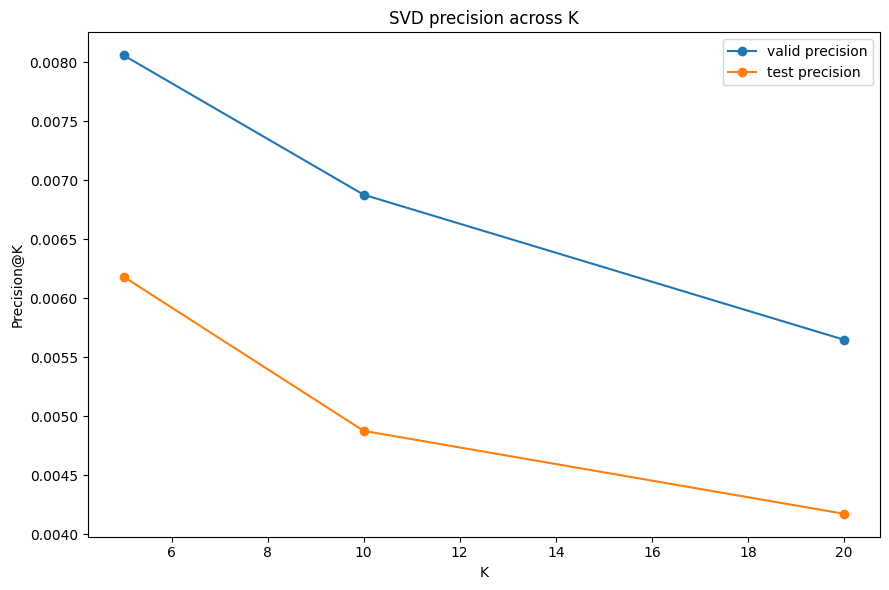

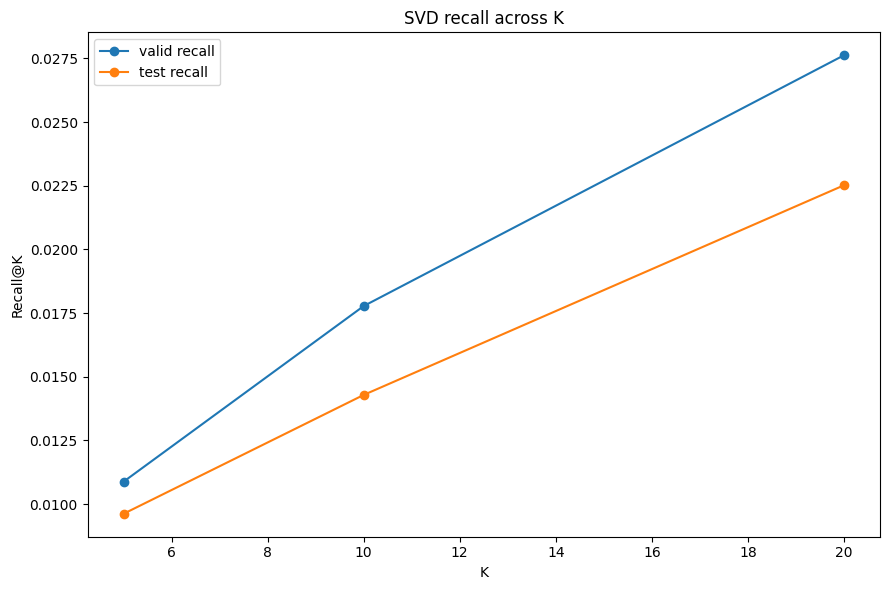

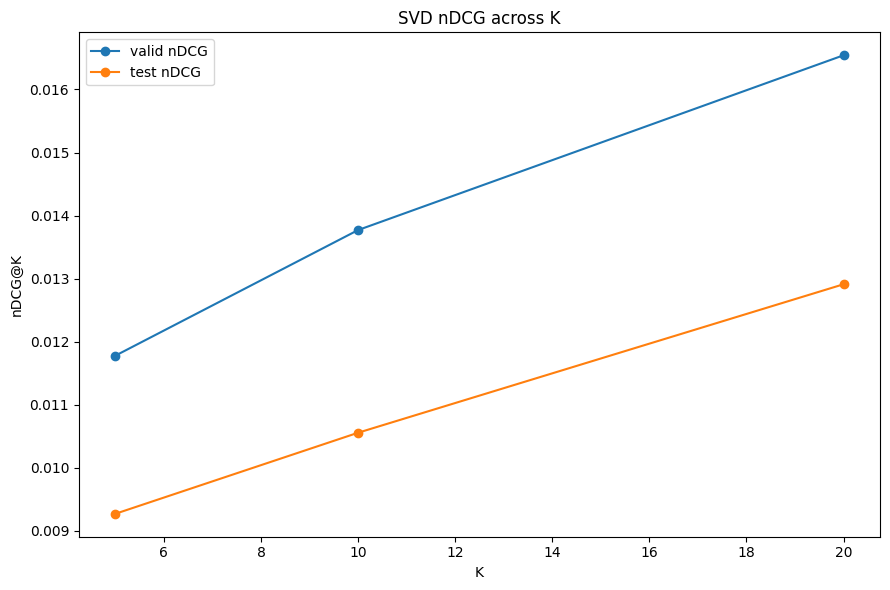

In [21]:
plt.figure(figsize=(9, 6))
for split_name in ["valid", "test"]:
    subset = svd_metrics[(svd_metrics["split"] == split_name)].copy()
    plt.plot(subset["k"], subset["precision_at_k"], marker="o", label=f"{split_name} precision")

plt.xlabel("K")
plt.ylabel("Precision@K")
plt.title("SVD precision across K")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for split_name in ["valid", "test"]:
    subset = svd_metrics[(svd_metrics["split"] == split_name)].copy()
    plt.plot(subset["k"], subset["recall_at_k"], marker="o", label=f"{split_name} recall")

plt.xlabel("K")
plt.ylabel("Recall@K")
plt.title("SVD recall across K")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for split_name in ["valid", "test"]:
    subset = svd_metrics[(svd_metrics["split"] == split_name)].copy()
    plt.plot(subset["k"], subset["ndcg_at_k"], marker="o", label=f"{split_name} nDCG")

plt.xlabel("K")
plt.ylabel("nDCG@K")
plt.title("SVD nDCG across K")
plt.legend()
plt.tight_layout()
plt.show()

## 16. Analyse recommendation popularity concentration

Inspect whether the SVD model still concentrates heavily on already-popular recipes or
spreads recommendations more broadly than the popularity baseline.

In [22]:
def build_recommendation_popularity_summary(
    recommendations_df: pd.DataFrame,
    split_name: str,
) -> pd.DataFrame:
    df = recommendations_df.copy()
    summary = (
        df.groupby("item_idx")
        .size()
        .reset_index(name="times_recommended")
        .merge(
            item_popularity[["item_idx", "train_interaction_count", "item_popularity_rank"]],
            on="item_idx",
            how="left",
        )
        .sort_values("times_recommended", ascending=False)
        .reset_index(drop=True)
    )
    summary["split"] = split_name
    return summary

valid_popularity_summary = build_recommendation_popularity_summary(
    valid_recommendations_export, "valid"
)
test_popularity_summary = build_recommendation_popularity_summary(
    test_recommendations_export, "test"
)

display(valid_popularity_summary.head(20))
display(test_popularity_summary.head(20))

,item_idx,times_recommended,train_interaction_count,item_popularity_rank,split
0,17050,6168,911,4,valid
1,14590,5995,672,10,valid
2,38707,5863,661,11,valid
3,38583,5751,687,9,valid
4,21107,5275,923,3,valid
5,43197,5131,524,14,valid
6,11404,5130,799,5,valid
7,13270,4936,688,8,valid
8,37647,4895,754,6,valid
9,29869,4824,725,7,valid


,item_idx,times_recommended,train_interaction_count,item_popularity_rank,split
0,17050,2858,911,4,test
1,14590,2841,672,10,test
2,38583,2743,687,9,test
3,38707,2735,661,11,test
4,11404,2471,799,5,test
5,21107,2459,923,3,test
6,43197,2425,524,14,test
7,13270,2357,688,8,test
8,29869,2278,725,7,test
9,37647,2239,754,6,test


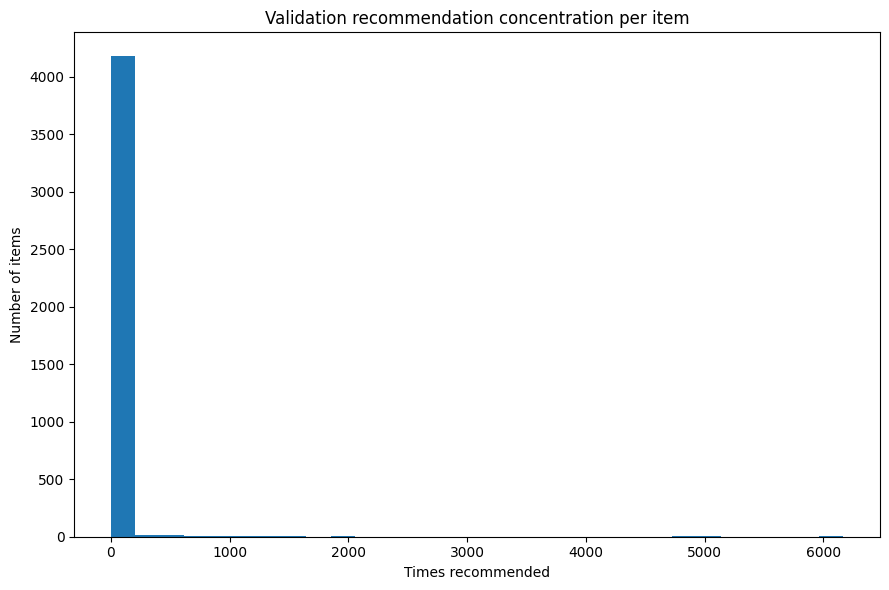

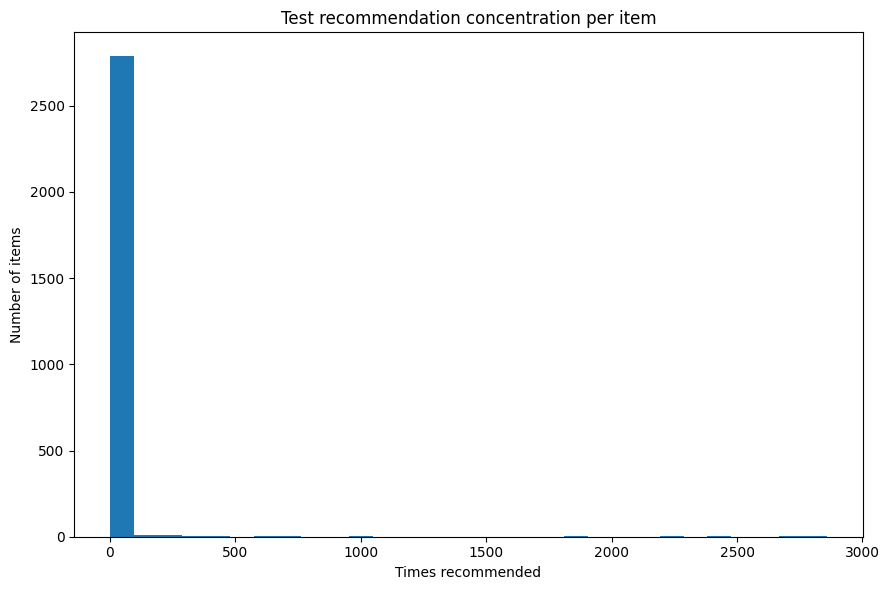

In [23]:
plt.figure(figsize=(9, 6))
plt.hist(valid_popularity_summary["times_recommended"], bins=30)
plt.xlabel("Times recommended")
plt.ylabel("Number of items")
plt.title("Validation recommendation concentration per item")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
plt.hist(test_popularity_summary["times_recommended"], bins=30)
plt.xlabel("Times recommended")
plt.ylabel("Number of items")
plt.title("Test recommendation concentration per item")
plt.tight_layout()
plt.show()

## 17. Build a compact run summary

In [24]:
run_summary = {
    "model": "svd_matrix_factorisation",
    "train_rows": int(len(train_svd)),
    "valid_rows_svd_evaluable": int(len(valid_svd)),
    "test_rows_svd_evaluable": int(len(test_svd)),
    "train_users": int(train_svd["user_id"].nunique()),
    "train_items": int(train_svd["recipe_id"].nunique()),
    "matrix_shape": [int(train_matrix.shape[0]), int(train_matrix.shape[1])],
    "matrix_nnz": int(train_matrix.nnz),
    "n_components": int(N_COMPONENTS),
    "n_iter": int(N_ITER),
    "explained_variance_ratio_sum": float(svd_model.explained_variance_ratio_.sum()),
    "top_k_values": TOP_K_VALUES,
    "metrics": svd_metrics.to_dict(orient="records"),
}

run_summary

{'model': 'svd_matrix_factorisation',
 'train_rows': 792656,
 'valid_rows_svd_evaluable': 86979,
 'test_rows_svd_evaluable': 35728,
 'train_users': 106304,
 'train_items': 186564,
 'matrix_shape': [106304, 186564],
 'matrix_nnz': 792656,
 'n_components': 64,
 'n_iter': 10,
 'explained_variance_ratio_sum': 0.1318843091974922,
 'top_k_values': [5, 10, 20],
 'metrics': [{'split': 'valid',
   'k': 5,
   'users_evaluated': 12779,
   'precision_at_k': 0.008060098599264418,
   'recall_at_k': 0.010880407339215066,
   'hit_rate_at_k': 0.03810939823147351,
   'ndcg_at_k': 0.011777267281403438,
   'novelty_at_k': 10.558164439592659,
   'catalog_coverage_at_k': 0.01042001672348363,
   'recommendation_count': 63895},
  {'split': 'valid',
   'k': 10,
   'users_evaluated': 12779,
   'precision_at_k': 0.006878472493935363,
   'recall_at_k': 0.017777705680521227,
   'hit_rate_at_k': 0.061898427106972374,
   'ndcg_at_k': 0.0137699881124315,
   'novelty_at_k': 10.989531914303583,
   'catalog_coverage_at_

## 18. Save outputs

Save metrics, recommendation exports, component summaries, coverage summaries, and the
compact JSON run log.

In [25]:
coverage_summary.to_csv(TABLES_SUBDIR / "09_svd_mapping_coverage_summary.csv", index=False)
component_summary.to_csv(TABLES_SUBDIR / "09_svd_component_summary.csv", index=False)
svd_metrics.to_csv(TABLES_SUBDIR / "09_svd_metrics.csv", index=False)
valid_recommendations_export.to_csv(
    TABLES_SUBDIR / "09_svd_valid_recommendations.csv",
    index=False,
)
test_recommendations_export.to_csv(
    TABLES_SUBDIR / "09_svd_test_recommendations.csv",
    index=False,
)
valid_popularity_summary.to_csv(
    TABLES_SUBDIR / "09_svd_valid_recommendation_popularity.csv",
    index=False,
)
test_popularity_summary.to_csv(
    TABLES_SUBDIR / "09_svd_test_recommendation_popularity.csv",
    index=False,
)

with open(LOGS_SUBDIR / "09_svd_run_log.json", "w", encoding="utf-8") as f:
    json.dump(run_summary, f, indent=2)

print("Saved SVD outputs.")

Saved SVD outputs.


## 19. Final summary

This notebook implemented a truncated-SVD matrix factorisation recommender using the
chronological implicit training split.

Key modelling decisions in this phase:
- the model was fitted on implicit train data only
- train-fitted user and item mappings from Phase 5 were reused
- validation and test rows without train-known mappings were quantified explicitly
- latent user and item factors were learned from the sparse user-item matrix
- recommendations excluded items already seen in training
- evaluation used Top-N ranking metrics on validation and test
- catalogue coverage, novelty, and recommendation concentration were also inspected

These outputs are now ready for:
- direct comparison against the popularity baseline
- direct comparison against collaborative filtering
- weighted hybrid score combination in the next phase
- dashboard-ready model comparison tables and figures